# Summary

This notebook contains a summary of the entire repository for the BNPL project

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sys, os, glob
import re
import math
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, LongType, IntegerType, DateType, DoubleType

In [2]:
sys.path.insert(0, "../scripts")
from spark_setup import get_spark
spark = get_spark()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/18 07:08:38 WARN Utils: Your hostname, tray, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/09/18 07:08:38 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/18 07:08:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Preprocessing

On preprocessing all the data the following records are left in the dataset

In [3]:
# merchant data set
df_merchants = spark.read.parquet('.././data/curated/df_merchants')
df_merchants.count()

4026

In [4]:
# consumer
df_customers = spark.read.parquet('.././data/curated/df_customers')
df_customers.count()

34864

In [5]:
# full transactions (after join w merchant and consumers)
df_transactions = spark.read.parquet('.././data/curated/df_transactions')
df_transactions.count()

71816

All tables have been checked to ensure that all records are valid. Invalid merchants were removed.

Joining the original data:
The data was joined on order_datetime and ids for merchants and consumers

In [6]:
df_transactions.printSchema()

root
 |-- merchant_abn: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- order_datetime: date (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- consumer_id: long (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- postcode: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- merchant_name: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- category: string (nullable = true)
 |-- revenue_band: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- category_group: string (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- n_transactions: long (nullable = true)
 |-- avg_order_value: double (nullable = true)
 |-- avg_merchant_fraud_prob: double (nullable = true)



In [7]:
df_transactions.filter(F.isnull('avg_merchant_fraud_prob')).count()

65518

In [8]:
df_transactions.filter(F.isnull('fraud_probability')).count()

0

13610826 merchant frauds were null and 13543038 consumer frauds were null and needed to be imputed.

## External datasets:
**Census Data:** This data was combined with our original data using consumer postocde and was used to retrieve features such as household size, family earnings and age.

In [9]:
final_merged = spark.read.parquet('.././data/curated/final_external_enriched')
final_merged.show()

26/09/18 07:09:03 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------------+--------+------------+-------+------------------+--------------------+-----------+------------------+---------------------+---------------+--------------------+-----+------+--------------------+--------------------+--------------------+------------+---------+-------------------+------------------+--------------+------------------+-----------------------+-------------+------------------+-----------------------------+---------------------------+------------------+-------------------------+----------------------------+-------------------------+----------------------+----------+--------------+------------------+----------------+--------------+---------------+------------------+--------------+-------------+--------------+-----------------+---------------+-----------------+
|order_datetime|postcode|merchant_abn|user_id|      dollar_value|            order_id|consumer_id| fraud_probability|is_same_day_duplicate|           name|             address|state|gender|       merchant_

In [10]:
final_merged.printSchema()

root
 |-- order_datetime: date (nullable = true)
 |-- postcode: string (nullable = true)
 |-- merchant_abn: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- dollar_value: double (nullable = true)
 |-- order_id: string (nullable = true)
 |-- consumer_id: long (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- merchant_name: string (nullable = true)
 |-- tags: string (nullable = true)
 |-- category: string (nullable = true)
 |-- revenue_band: string (nullable = true)
 |-- take_rate: double (nullable = true)
 |-- category_group: string (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- n_transactions: long (nullable = true)
 |-- avg_order_value: double (nullable = true)
 |-- avg_merchant_fraud_prob: double (nullable = true)
 |-- SA

In [11]:
final_merged.select(
    F.count("*").alias("total_rows"),
    F.sum(F.col("SA2_CODE_2021").isNull().cast("int")).alias("missing_census"),
    F.sum(F.col("poa_irsad_score").isNull().cast("int")).alias("missing_seifa"),
    F.sum(F.col("rba_cash_rate_pct").isNull().cast("int")).alias("missing_rba"),
    F.sum(F.col("avg_merchant_fraud_prob").isNull().cast("int")).alias("missing_fraud_label"),
).show()

+----------+--------------+-------------+-----------+-------------------+
|total_rows|missing_census|missing_seifa|missing_rba|missing_fraud_label|
+----------+--------------+-------------+-----------+-------------------+
|     93431|         37544|        12367|          0|              85265|
+----------+--------------+-------------+-----------+-------------------+



## Exploratory Analysis

This section contains a summary on some of the features studied, `tbc`

**Transaction Level Distributions**

/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


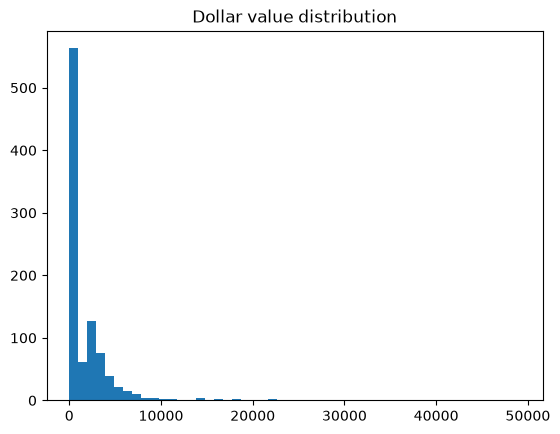

In [12]:
pdf = final_merged.select("dollar_value").sample(0.01).toPandas()  # sample first, full table is large
plt.hist(pdf["dollar_value"], bins=50)
plt.title("Dollar value distribution")
plt.show()

/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


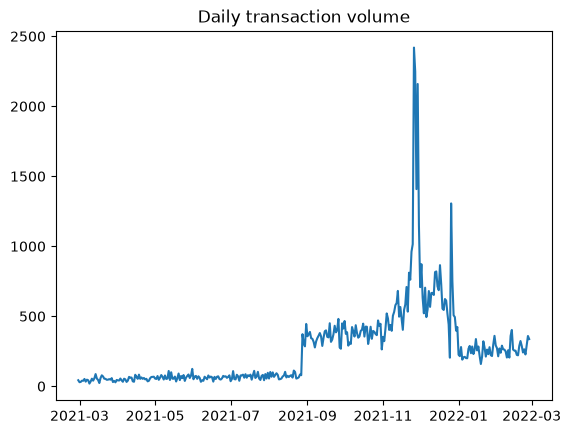

In [13]:
daily = (
    final_merged
    .groupBy("order_datetime")
    .agg(F.count("*").alias("n_txn"), F.sum("dollar_value").alias("total_value"))
    .orderBy("order_datetime")
    .toPandas()
)
plt.plot(daily["order_datetime"], daily["n_txn"])
plt.title("Daily transaction volume")
plt.show()

**Merchant Landscape**

In [14]:
(final_merged.groupBy("category_group")
    .agg(F.sum("dollar_value").alias("revenue"), F.countDistinct("merchant_abn").alias("n_merchants"))
    .orderBy(F.desc("revenue"))
    .show(20, truncate=False))

+------------------------+--------------------+-----------+
|category_group          |revenue             |n_merchants|
+------------------------+--------------------+-----------+
|antiques_art_craft      |4.333526564287774E7 |358        |
|jewelry                 |2.694240381114229E7 |225        |
|tv_media_telecom        |2.1990607491991058E7|271        |
|vehicle                 |1.9257669184479527E7|260        |
|equipment_rental_leasing|1.5962822602050858E7|127        |
|furniture_home          |1.1356687417931266E7|146        |
|outdoor_supply          |9125094.909304183   |157        |
|gardening               |8373438.220663373   |260        |
|gifts_hobby_novelty     |7672232.53192921    |292        |
|music                   |2379166.4261947465  |133        |
|health_beauty           |1696905.5072584967  |344        |
|technology              |1547137.9737849594  |279        |
|office_stationery       |1312246.972576325   |107        |
|footwear                |541087.8992828

**Consumer Demographics**

In [15]:
final_merged.groupBy("state", "gender").agg(F.countDistinct("consumer_id").alias("n_consumers")).show()

+-----+-----------+-----------+
|state|     gender|n_consumers|
+-----+-----------+-----------+
|   WA|       Male|       1422|
|  QLD|       Male|       1280|
|  ACT|     Female|         84|
|  TAS|Undisclosed|         77|
|   SA|     Female|        984|
|  VIC|Undisclosed|        470|
|   WA|Undisclosed|        305|
|   NT|     Female|        124|
|  NSW|Undisclosed|        559|
|  NSW|     Female|       2480|
|  QLD|     Female|       1292|
|   NT|Undisclosed|         28|
|   SA|Undisclosed|        250|
|   NT|       Male|        114|
|  VIC|       Male|       2050|
|   WA|     Female|       1367|
|  ACT|Undisclosed|         20|
|  VIC|     Female|       2009|
|  NSW|       Male|       2586|
|  QLD|Undisclosed|        291|
+-----+-----------+-----------+
only showing top 20 rows


**Socioeconomic**

In [16]:
(final_merged
    .filter(F.col("poa_irsad_decile").isNotNull())
    .groupBy("poa_irsad_decile")
    .agg(
        F.avg("dollar_value").alias("avg_spend"),
        F.avg("fraud_probability").alias("avg_fraud_prob"),
        F.avg("Median_tot_hhd_inc_weekly").alias("avg_hhd_income"),
        F.avg("prop_18_34").alias("avg_prop_young"),
    )
    .orderBy("poa_irsad_decile")
    .show())

+----------------+------------------+------------------+------------------+-------------------+
|poa_irsad_decile|         avg_spend|    avg_fraud_prob|    avg_hhd_income|     avg_prop_young|
+----------------+------------------+------------------+------------------+-------------------+
|             1.0|1830.0291455215354|14.702307422885887|1261.3733852778348|0.21311053693984655|
|             2.0|1907.8863438985225|14.576353395097417|1294.9047120418847|0.18994429319371728|
|             3.0|1879.0042281987662|14.737973302306106|1400.0121227753418|0.19132563315425943|
|             4.0|1837.8383755351106|14.567424400047502|1475.8741627765376|0.20117145753091437|
|             5.0|1881.4544804314926|14.927305087055096|1648.8553153153152|0.20446612266857972|
|             6.0|1872.1374466937605|14.933262511491808|1732.4562804284324| 0.2180446613312513|
|             7.0|1838.2143369849805| 14.42427959476939|1797.7740842684734|0.21291442287177292|
|             8.0|1762.7464747210543|14.

**RBA Rate**

In [17]:
(final_merged.groupBy("rba_rate_hike_day")
    .agg(F.avg("dollar_value").alias("avg_txn_value"), F.count("*").alias("n_txn"))
    .show())

+-----------------+------------------+-----+
|rba_rate_hike_day|     avg_txn_value|n_txn|
+-----------------+------------------+-----+
|                0|1839.0684697400457|93431|
+-----------------+------------------+-----+



**Fraud**

In [18]:
final_merged.stat.corr("fraud_probability", "poa_irsad_score")
final_merged.groupBy("category_group").agg(F.avg("avg_merchant_fraud_prob").alias("avg_fraud")).orderBy(F.desc("avg_fraud")).show()

+--------------------+------------------+
|      category_group|         avg_fraud|
+--------------------+------------------+
|             jewelry|41.695453749905525|
|             vehicle| 37.62612834221612|
|  antiques_art_craft| 37.05060807326267|
|            footwear|31.343502316867777|
|      outdoor_supply|    31.19525978037|
|    tv_media_telecom|31.158614155434865|
|           gardening|31.104531896402808|
| gifts_hobby_novelty|30.893075891056302|
|          technology| 30.02048909832398|
|      furniture_home| 29.83668436522115|
|       health_beauty|29.438004367461176|
|   office_stationery|28.880648130522033|
| books_media_digital|              NULL|
|               music|              NULL|
|equipment_rental_...|              NULL|
+--------------------+------------------+



/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


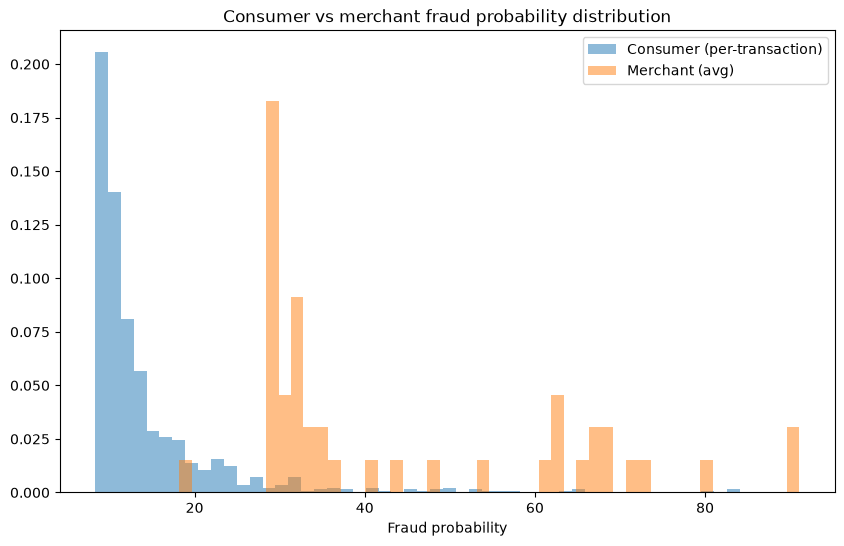

In [19]:
pdf_consumer = final_merged.select("fraud_probability").sample(0.01).toPandas()
pdf_merchant = (
    final_merged.select("merchant_abn", "avg_merchant_fraud_prob")
    .distinct()
    .toPandas()
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(pdf_consumer["fraud_probability"], bins=50, alpha=0.5, label="Consumer (per-transaction)", density=True)
ax.hist(pdf_merchant["avg_merchant_fraud_prob"].dropna(), bins=50, alpha=0.5, label="Merchant (avg)", density=True)
ax.set_xlabel("Fraud probability")
ax.legend()
ax.set_title("Consumer vs merchant fraud probability distribution")
plt.show()

/tmp/ipykernel_5290/3973819333.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(pdf_consumer["fraud_probability"].dropna(), vert=True)
/tmp/ipykernel_5290/3973819333.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(pdf_merchant["avg_merchant_fraud_prob"].dropna(), vert=True)


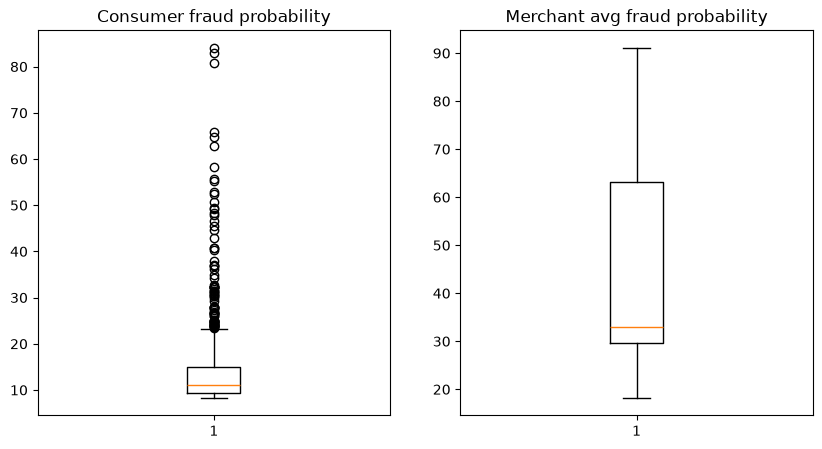

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].boxplot(pdf_consumer["fraud_probability"].dropna(), vert=True)
axes[0].set_title("Consumer fraud probability")
axes[1].boxplot(pdf_merchant["avg_merchant_fraud_prob"].dropna(), vert=True)
axes[1].set_title("Merchant avg fraud probability")
plt.show()

/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


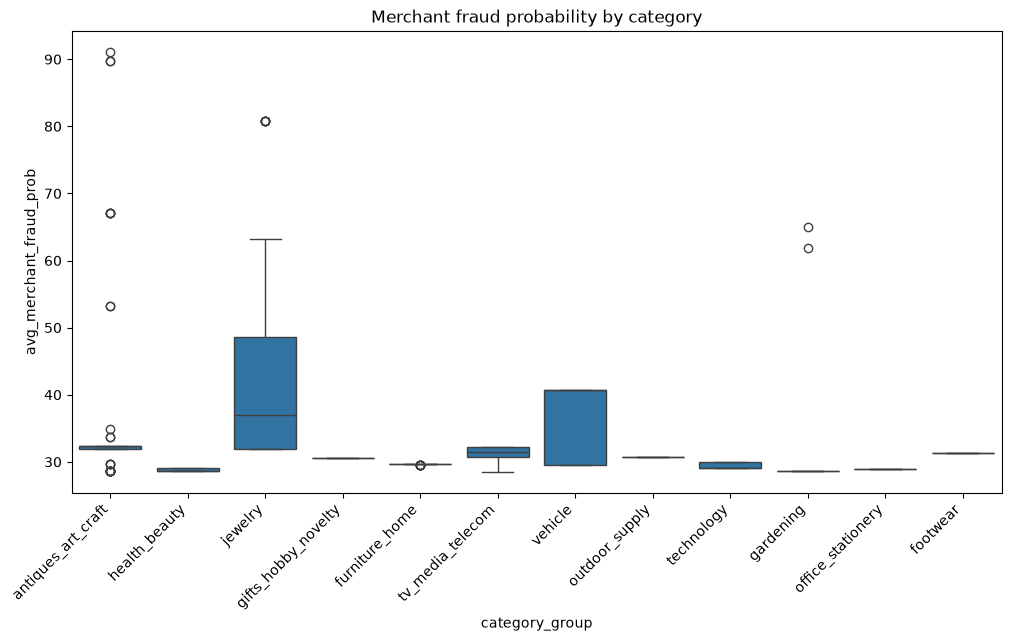

In [21]:
pdf_cat = (
    final_merged.select("category_group", "avg_merchant_fraud_prob")
    .dropna()
    .sample(0.05)
    .toPandas()
)

import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(data=pdf_cat, x="category_group", y="avg_merchant_fraud_prob")
plt.xticks(rotation=45, ha="right")
plt.title("Merchant fraud probability by category")
plt.show()

/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


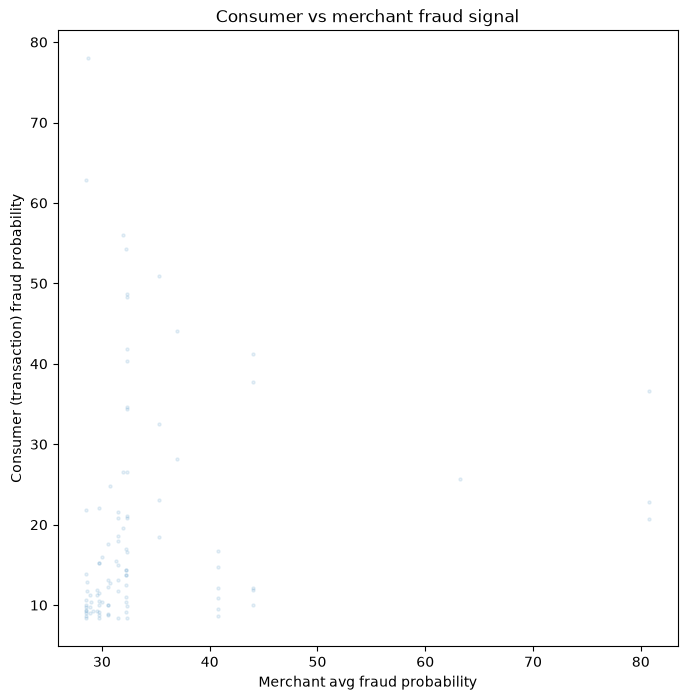

0.14509208501838375


In [22]:
pdf_both = (
    final_merged.select("fraud_probability", "avg_merchant_fraud_prob")
    .dropna()
    .sample(0.01)
    .toPandas()
)

plt.figure(figsize=(8, 8))
plt.scatter(pdf_both["avg_merchant_fraud_prob"], pdf_both["fraud_probability"], alpha=0.1, s=5)
plt.xlabel("Merchant avg fraud probability")
plt.ylabel("Consumer (transaction) fraud probability")
plt.title("Consumer vs merchant fraud signal")
plt.show()

print(final_merged.stat.corr("fraud_probability", "avg_merchant_fraud_prob"))

**Geospatial Analysis**

Spend per capita grouuped by postcode

In [41]:
import geopandas as gpd

# aggregate at postcode level in Spark
postcode_stats = (
    final_merged
    .groupBy("postcode")
    .agg(
        F.sum("dollar_value").alias("total_spend"),
        F.count("*").alias("n_txn"),
        F.avg("fraud_probability").alias("avg_fraud_prob"),
        F.avg("poa_population").alias("population"),
    )
    .toPandas()
)

postcode_stats["spend_per_capita"] = postcode_stats["total_spend"] / postcode_stats["population"]

/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


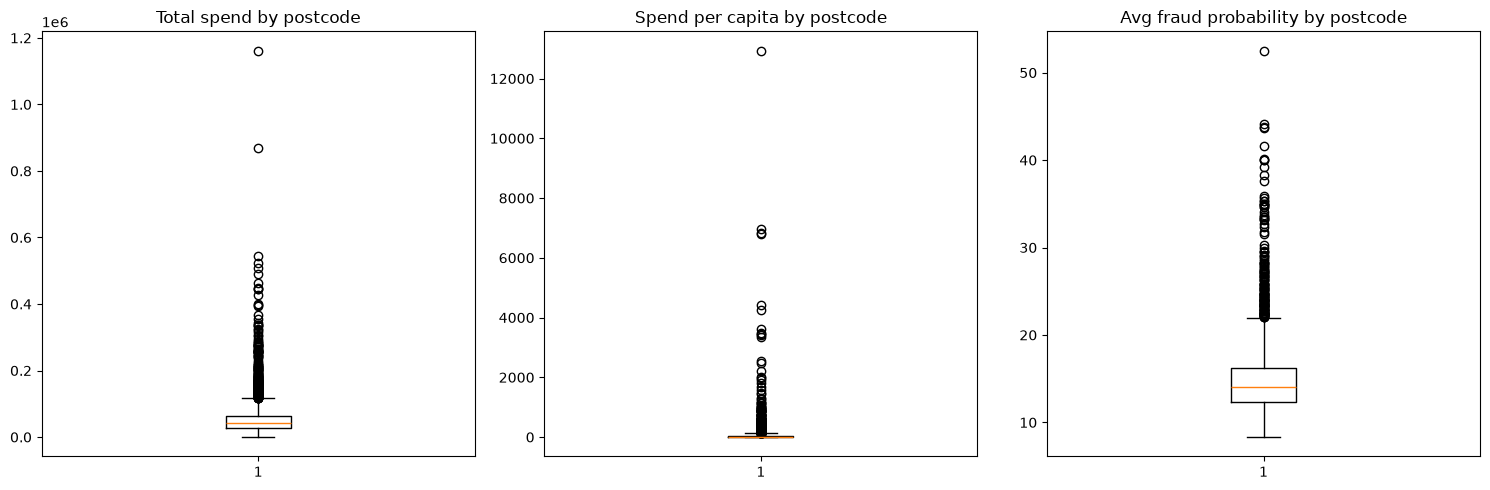

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].boxplot(postcode_stats["total_spend"].dropna())
axes[0].set_title("Total spend by postcode")

axes[1].boxplot(postcode_stats["spend_per_capita"].dropna())
axes[1].set_title("Spend per capita by postcode")

axes[2].boxplot(postcode_stats["avg_fraud_prob"].dropna())
axes[2].set_title("Avg fraud probability by postcode")

plt.tight_layout()
plt.show()

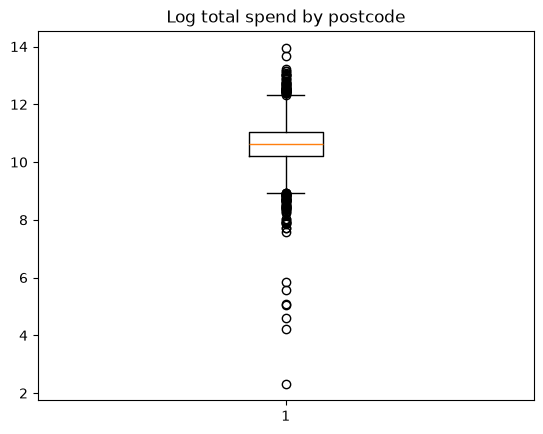

In [43]:
# transform data to fix skewness
postcode_stats["log_total_spend"] = np.log1p(postcode_stats["total_spend"])

plt.boxplot(postcode_stats["log_total_spend"].dropna())
plt.title("Log total spend by postcode")
plt.show()

In [44]:
# filter out small population
postcode_stats.sort_values("spend_per_capita", ascending=False).head(10)[["postcode", "population", "total_spend", "spend_per_capita"]]

# a) filter out unreliable small-population postcodes before computing per-capita
postcode_stats_filtered = postcode_stats[postcode_stats["population"] >= 100].copy()

# b) then log-transform what's left
postcode_stats_filtered["log_spend_per_capita"] = np.log1p(postcode_stats_filtered["spend_per_capita"])

In [45]:
poa = gpd.read_file("../data/landing/POA_2021_AUST_GDA2020.shp")[["POA_CODE21", "geometry"]]
poa = poa.rename(columns={"POA_CODE21": "postcode"})

poa_geo = poa.merge(postcode_stats, on="postcode", how="left")

In [46]:
# for spend-per-capita and orders-per-capita maps
poa_geo_filtered = poa.merge(postcode_stats_filtered, on="postcode", how="left")

# for total spend and fraud maps (no population filter needed)
poa_geo = poa.merge(postcode_stats, on="postcode", how="left")

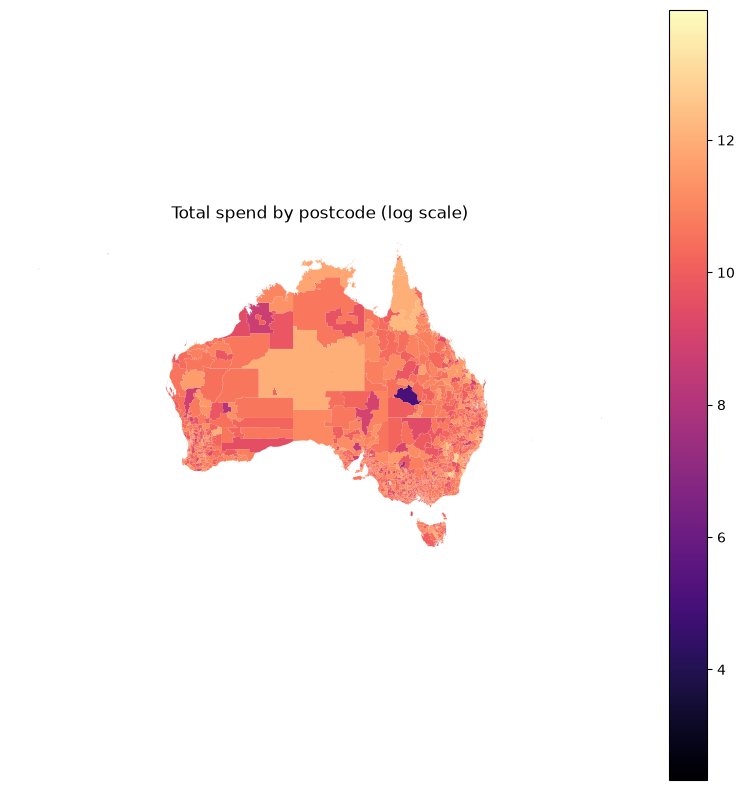

In [47]:
fig, ax = plt.subplots(figsize=(10, 10))
poa_geo.plot(column="log_total_spend", cmap="magma", legend=True, ax=ax,
             missing_kwds={"color": "lightgrey"})
ax.set_title("Total spend by postcode (log scale)")
ax.axis("off")
plt.show()

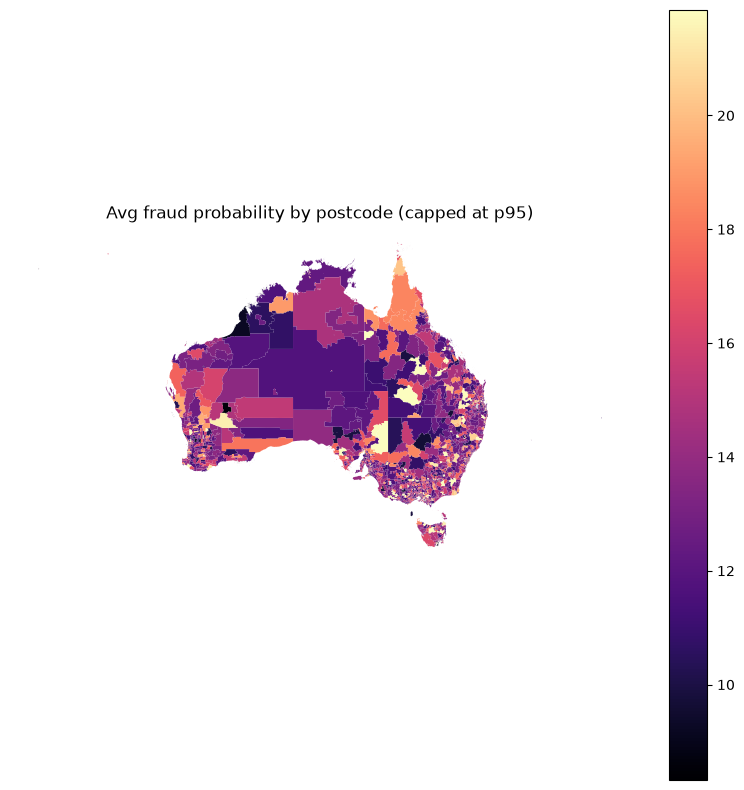

In [48]:
fig, ax = plt.subplots(figsize=(10, 10))
vmax = poa_geo["avg_fraud_prob"].quantile(0.95)
poa_geo.plot(column="avg_fraud_prob", cmap="magma", legend=True, vmax=vmax, ax=ax,
             missing_kwds={"color": "lightgrey"})
ax.set_title("Avg fraud probability by postcode (capped at p95)")
ax.axis("off")
plt.show()

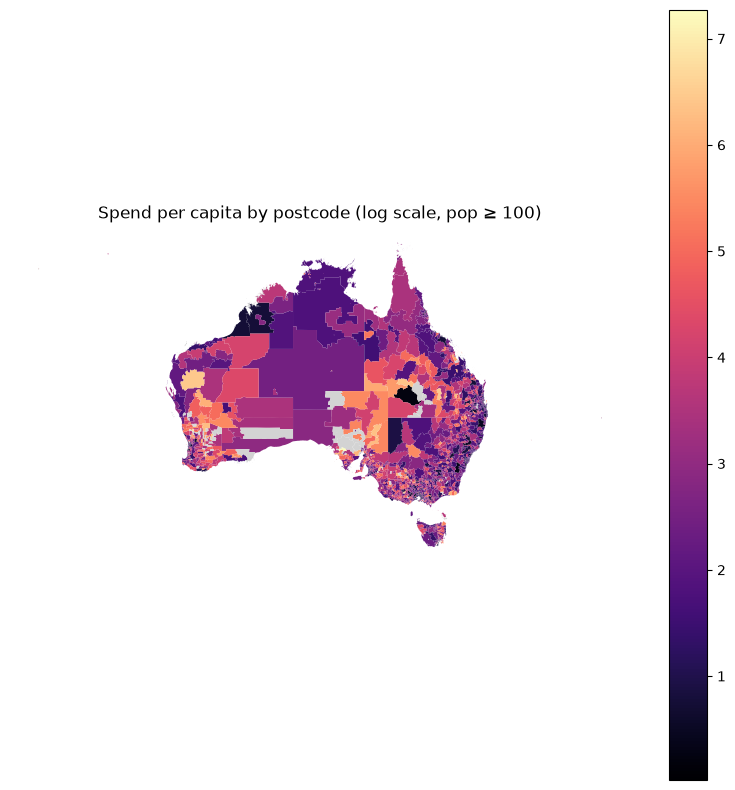

In [49]:
fig, ax = plt.subplots(figsize=(10, 10))
poa_geo_filtered.plot(column="log_spend_per_capita", cmap="magma", legend=True, ax=ax,
                       missing_kwds={"color": "lightgrey"})
ax.set_title("Spend per capita by postcode (log scale, pop ≥ 100)")
ax.axis("off")
plt.show()

Orders per capita grouuped by postcode

In [50]:
postcode_stats["orders_per_capita"] = postcode_stats["n_txn"] / postcode_stats["population"]
postcode_stats["log_n_txn"] = np.log1p(postcode_stats["n_txn"])

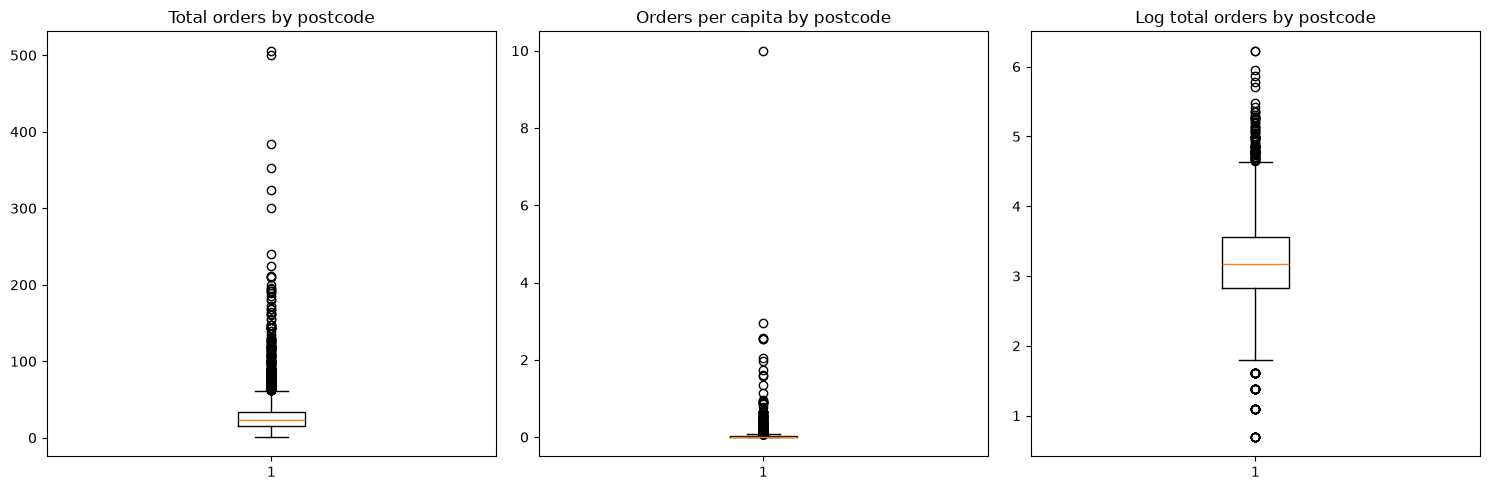

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].boxplot(postcode_stats["n_txn"].dropna())
axes[0].set_title("Total orders by postcode")

axes[1].boxplot(postcode_stats["orders_per_capita"].dropna())
axes[1].set_title("Orders per capita by postcode")

axes[2].boxplot(postcode_stats["log_n_txn"].dropna())
axes[2].set_title("Log total orders by postcode")

plt.tight_layout()
plt.show()

In [52]:
postcode_stats.sort_values("orders_per_capita", ascending=False).head(10)[
    ["postcode", "population", "n_txn", "orders_per_capita"]
]

,postcode,population,n_txn,orders_per_capita
2301,6452,4.0,40,10.000000
2456,6470,20.0,59,2.950000
1899,4479,7.0,18,2.571429
1833,6385,20.0,51,2.550000
1401,4009,11.0,28,2.545455
2251,5713,20.0,41,2.050000
2160,3415,36.0,71,1.972222
1137,6628,23.0,40,1.739130
1116,6467,30.0,48,1.600000
520,4493,19.0,30,1.578947


In [53]:
# reuse the population filter already applied for spend-per-capita
postcode_stats_filtered["orders_per_capita"] = (
    postcode_stats_filtered["n_txn"] / postcode_stats_filtered["population"]
)
postcode_stats_filtered["log_orders_per_capita"] = np.log1p(
    postcode_stats_filtered["orders_per_capita"]
)

In [54]:
poa_geo = poa.merge(postcode_stats, on="postcode", how="left")
poa_geo_filtered = poa.merge(postcode_stats_filtered, on="postcode", how="left")

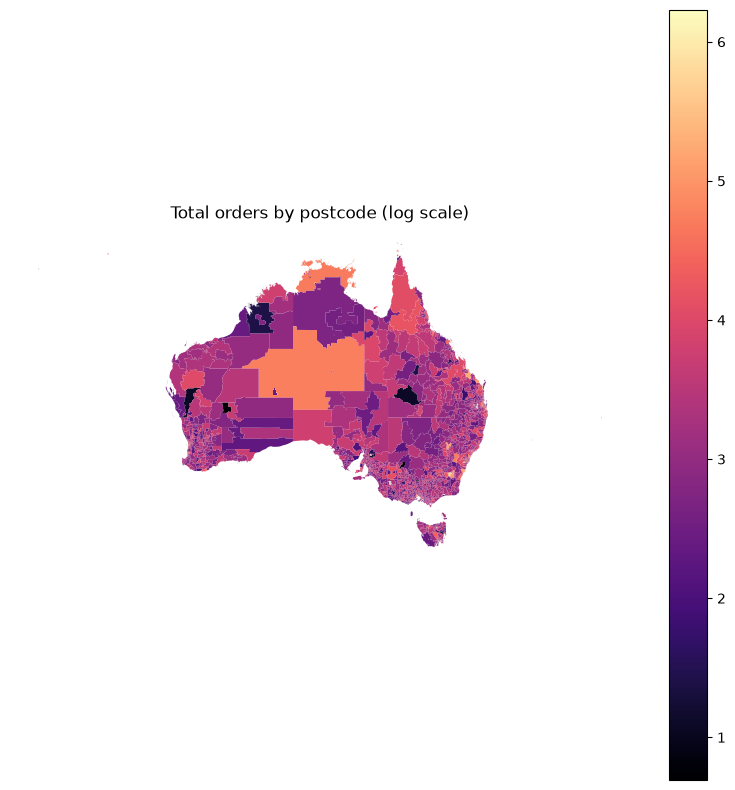

Text(731.5277777777778, 0.5, 'log(total orders + 1)')

In [61]:
fig, ax = plt.subplots(figsize=(10, 10))
poa_geo.plot(column="log_n_txn", cmap="magma", legend=True, ax=ax,
             missing_kwds={"color": "lightgrey"})
ax.set_title("Total orders by postcode (log scale)")
ax.axis("off")
plt.show()

cbar = ax.get_figure().axes[-1]
cbar.set_ylabel("log(total orders + 1)")

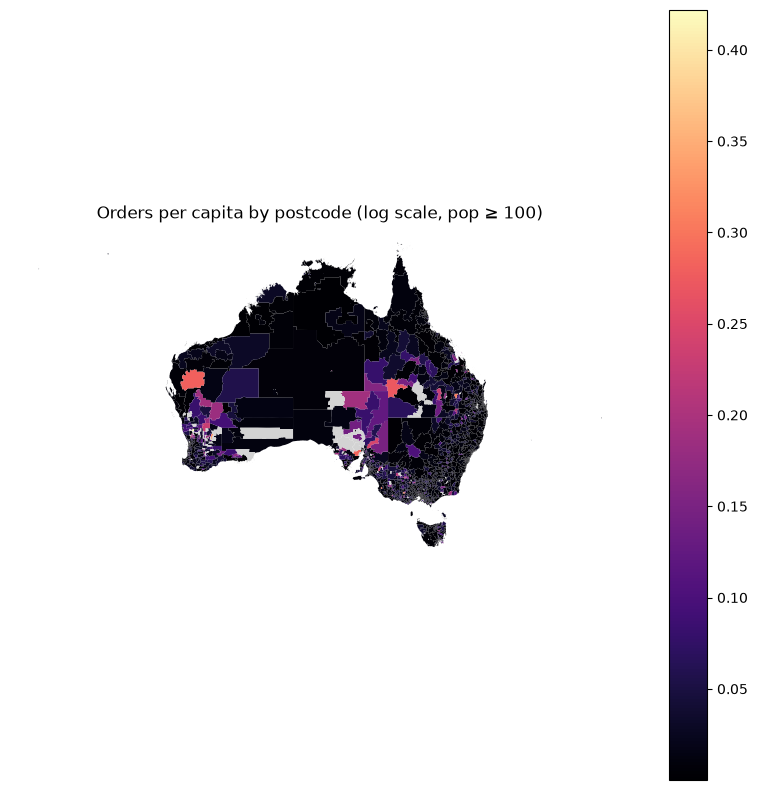

Text(753.5277777777778, 0.5, 'log(orders per capita + 1)')

In [56]:
fig, ax = plt.subplots(figsize=(10, 10))
poa_geo_filtered.plot(column="log_orders_per_capita", cmap="magma", legend=True, ax=ax,
                       missing_kwds={"color": "lightgrey"})
ax.set_title("Orders per capita by postcode (log scale, pop ≥ 100)")
ax.axis("off")
plt.show()

cbar = ax.get_figure().axes[-1]
cbar.set_ylabel("log(orders per capita + 1)")